# RelayBP Hyperparameter Tuning

Three-phase workflow for tuning the RelayBP decoder on BB code [[144, 12, 12]] with circuit-level noise:
1. **Phase 1** — Sweep `gamma0` to find the optimal MemBP memory strength
2. **Phase 2** — Optimize `gamma_dist_interval` using Nevergrad
3. **Phase 3** — Compare RelayBP vs MemBP vs BP+OSD across error rates

In [ ]:
%reload_ext autoreload
%autoreload 2
import os
from pathlib import Path
from math import prod

import numpy as np

import matplotlib.pyplot as plt
import sinter
import relay_bp

from qecdec.experiments import StimFileExperiment
from qecdec.decoders import BPDecoder, MemBPDecoder, BPOSDDecoder, RelayBPDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

Code parameters

In [2]:
n, k, d = 144, 12, 12
rounds = d
code_name = f"BB_{n}_{k}_{d}"
noise_model = "CircuitLevel"

# Physical error rate at which the decoder is tuned
opt_error_rate = 0.003

In [3]:
basis_to_circuit_dir = {
    basis: Path(
        f"../../../circuits/{code_name}_{noise_model}/d={d}_rounds={rounds}_basis={basis}"
    ).resolve()
    for basis in ["X", "Z"]
}

basis_to_opt_circuit_file = {
    basis: circ_dir / f"error_rate={opt_error_rate}.stim"
    for basis, circ_dir in basis_to_circuit_dir.items()
}

basis_to_opt_expmt = {
    basis: StimFileExperiment.load_from_file(circ_file, basis)
    for basis, circ_file in basis_to_opt_circuit_file.items()
}

Fixed RelayBP parameters

In [4]:
num_relays = 16
pre_iter = 50
max_iter_per_relay = 50
stop_nconv = 1

## Phase 1 — gamma0 sweep

In [5]:
# List of gamma0 values to sweep
membp_gamma0s = np.linspace(0, 1, 21).tolist()

In [ ]:
def generate_gamma0_sweep_tasks():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}

    for basis in ["X", "Z"]:
        expmt = StimFileExperiment.load_from_file(
            basis_to_opt_circuit_file[basis], basis
        )
        for gamma0 in membp_gamma0s:
            decoder = MemBPDecoder(
                expmt.chkmat,
                expmt.prior,
                gamma=gamma0,
                max_iter=pre_iter,
            )
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
                decoder, expmt.obsmat
            )
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder=custom_decoder_id,
                    json_metadata={"basis": basis, "gamma0": gamma0},
                )
            )
    return tasks, custom_decoders


tasks, custom_decoders = generate_gamma0_sweep_tasks()

In [ ]:
gamma0_sweep_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=True,
)

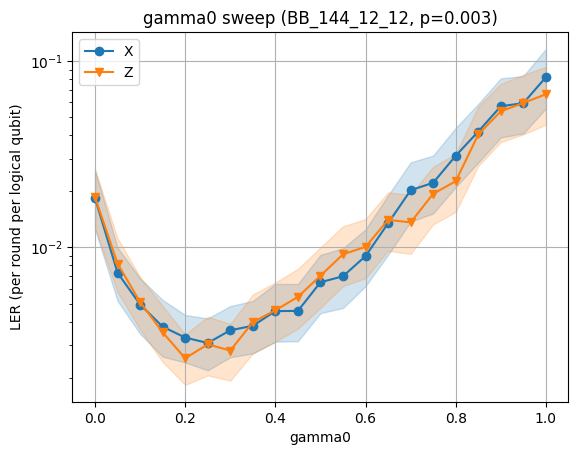

In [8]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=gamma0_sweep_stats,
    group_func=lambda stat: stat.json_metadata["basis"],
    failure_units_per_shot_func=lambda _: rounds,
    failure_values_func=lambda _: k,
    x_func=lambda stat: stat.json_metadata["gamma0"],
)
ax.semilogy()
ax.grid()
ax.set_ylabel("LER (per round per logical qubit)")
ax.set_xlabel("gamma0")
ax.set_title(f"gamma0 sweep ({code_name}, p={opt_error_rate})")
ax.legend()

plt.show()

In [9]:
# Pick the best gamma0 (manually from the plot above)
gamma0_star = 0.2  # <-- UPDATE THIS after inspecting the plot

## Phase 2 — Optimization of gamma_dist_interval

In [10]:
import nevergrad as ng

opt_budget = 100
opt_raw_shots = 25_000


In [ ]:
basis_to_training_data: dict[str, tuple[np.ndarray, np.ndarray]] = {}

for basis in ["X", "Z"]:
    expmt = basis_to_opt_expmt[basis]
    sampler = expmt.dem.compile_sampler()
    syndromes, observables, _ = sampler.sample(opt_raw_shots)
    syndromes, observables = syndromes.astype(np.uint8), observables.astype(np.uint8)

    # Only use samples that fail MemBP to train RelayBP
    membp = MemBPDecoder(
        expmt.chkmat,
        expmt.prior,
        gamma=gamma0_star,
        max_iter=pre_iter,
    )
    ehat = membp.decode_batch(syndromes)
    predicted_observables = (ehat @ expmt.obsmat.T) % 2
    mask = np.any(observables != predicted_observables, axis=1)
    print(
        f"For basis {basis}, out of {opt_raw_shots} there are {np.sum(mask)} failing MemBP shots to train with."
    )
    basis_to_training_data[basis] = (syndromes[mask], observables[mask])


For basis X, out of 25000 there are 852 failing MemBP shots to train with.
For basis Z, out of 25000 there are 926 failing MemBP shots to train with.


In [12]:
def cost_function(gdi_low: float, gdi_high: float) -> float:
    """Return the logical error rate for a given gamma_dist_interval."""
    print(f"Starting cost evaluation for {(gdi_low, gdi_high)}.")

    lers: list[float] = []

    for basis in ["X", "Z"]:
        expmt = basis_to_opt_expmt[basis]
        decoder = relay_bp.RelayDecoderF64(
            expmt.chkmat,
            expmt.prior,
            gamma0=gamma0_star,
            gamma_dist_interval=(gdi_low, gdi_high),
            num_sets=num_relays,
            pre_iter=pre_iter,
            set_max_iter=max_iter_per_relay,
            stop_nconv=stop_nconv,
        )
        observable_decoder = relay_bp.ObservableDecoderRunner(
            decoder,
            expmt.obsmat,
            include_decode_result=False,
        )

        syndromes, observables = basis_to_training_data[basis]
        predicted_observables = observable_decoder.decode_observables_batch(
            syndromes, parallel=True
        )
        errors = np.sum(np.any(observables != predicted_observables, axis=1))
        lers.append(errors / opt_raw_shots)

    prob_at_least_one_error = 1 - prod(1 - p for p in lers)
    ler_per_round_per_logical_qubit = prob_at_least_one_error / (rounds * k)
    return ler_per_round_per_logical_qubit

In [13]:
init_gamma_dist_interval = (-0.25, 0.75)

params = ng.p.Instrumentation(
    gdi_low=ng.p.Scalar(init=init_gamma_dist_interval[0], lower=-0.5, upper=0.5),
    gdi_high=ng.p.Scalar(init=init_gamma_dist_interval[1], lower=0.0, upper=1.0),
)


def ensure_gamma_interval_ordered(vals):
    param_dict = vals[1]
    return param_dict["gdi_low"] < param_dict["gdi_high"]


params.register_cheap_constraint(ensure_gamma_interval_ordered)

optimizer = ng.optimizers.TwoPointsDE(parametrization=params, budget=opt_budget)
optimizer.register_callback("tell", ng.callbacks.ProgressBar())

recommendation = optimizer.minimize(cost_function, verbosity=2)

gdi_star = (recommendation[1]["gdi_low"].value, recommendation[1]["gdi_high"].value)
print(f"Optimized gamma_dist_interval: {gdi_star}")
print(f"LER per round per logical qubit: {cost_function(*gdi_star)}")

Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.17650953057677127, 0.964167927872385).


0it [00:00, ?it/s]

Updating fitness with value 7.120964444444489e-05
99 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 7.120964444444489e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.17650953057677127, 'gdi_high': 0.964167927872385})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.25316649063362756, 0.8601685490479009).


  2%|███▍                                                                                                                                                                        | 2/100 [00:05<04:46,  2.93s/it]

Updating fitness with value 4.742024444444403e-05
98 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 4.742024444444403e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.25316649063362756, 'gdi_high': 0.8601685490479009})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.26964536641192133, 0.8155564941862528).


...

Updating fitness with value 4.8527777777777735e-05
2 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 3.3848888888889095e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.19806670996164882, 'gdi_high': 0.6200937872049607})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.10303023831127076, 0.7792955410844892).


 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎ | 99/100 [11:15<00:06,  6.12s/it]

Updating fitness with value 7.01026444444447e-05
1 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 3.3848888888889095e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.19806670996164882, 'gdi_high': 0.6200937872049607})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.26780004686509, 0.6446940100959214).


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [11:21<00:00,  6.29s/it]

Updating fitness with value 4.93571444444447e-05
0 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 3.3848888888889095e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.19806670996164882, 'gdi_high': 0.6200937872049607})>
Optimized gamma_dist_interval: (-0.19806670996164882, 0.6200937872049607)
Starting cost evaluation for (-0.19806670996164882, 0.6200937872049607).
LER per round per logical qubit: 3.3848888888889095e-05


## Phase 3 — Comparison: RelayBP vs BP vs MemBP vs BPOSD

In [22]:
print(f"Optimized gamma0: {gamma0_star}, gamma_dist_interval: {gdi_star}")

Optimized gamma0: 0.2, gamma_dist_interval: (-0.19806670996164882, 0.6200937872049607)


In [ ]:
def generate_comparison_tasks(basis: str):
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}

    circuit_dir = basis_to_circuit_dir[basis]

    for p in [0.002, 0.003, 0.004, 0.005]:
        expmt = StimFileExperiment.load_from_file(
            circuit_dir / f"error_rate={p}.stim", basis
        )

        # BP
        bp = BPDecoder(expmt.chkmat, expmt.prior, max_iter=pre_iter)
        bp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[bp_id] = QecdecSinterDecoder(bp, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=bp_id,
                json_metadata={"p": p, "decoder": "BP"},
            )
        )

        # MemBP
        membp = MemBPDecoder(
            expmt.chkmat,
            expmt.prior,
            gamma=gamma0_star,
            max_iter=pre_iter,
        )
        membp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[membp_id] = QecdecSinterDecoder(membp, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=membp_id,
                json_metadata={"p": p, "decoder": "MemBP"},
            )
        )

        # BPOSD
        bposd = BPOSDDecoder(
            expmt.chkmat,
            expmt.prior,
            max_bp_iter=pre_iter,
            osd_method="OSD_CS",
            osd_order=10,
        )
        bposd_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[bposd_id] = QecdecSinterDecoder(bposd, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=bposd_id,
                json_metadata={"p": p, "decoder": "BPOSD"},
            )
        )

        # RelayBP
        relaybp = RelayBPDecoder(
            expmt.chkmat,
            expmt.prior,
            gamma0=gamma0_star,
            gamma_dist_interval=gdi_star,
            num_relays=num_relays,
            pre_iter=pre_iter,
            max_iter_per_relay=max_iter_per_relay,
            stop_nconv=stop_nconv,
        )
        relaybp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[relaybp_id] = QecdecSinterDecoder(relaybp, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=relaybp_id,
                json_metadata={"p": p, "decoder": "RelayBP"},
            )
        )

    return tasks, custom_decoders


In [ ]:
cmp_tasks_Z_basis, cmp_custom_decoders_Z_basis = generate_comparison_tasks("Z")

cmp_stats_Z_basis = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=cmp_tasks_Z_basis,
    custom_decoders=cmp_custom_decoders_Z_basis,
    print_progress=True,
)

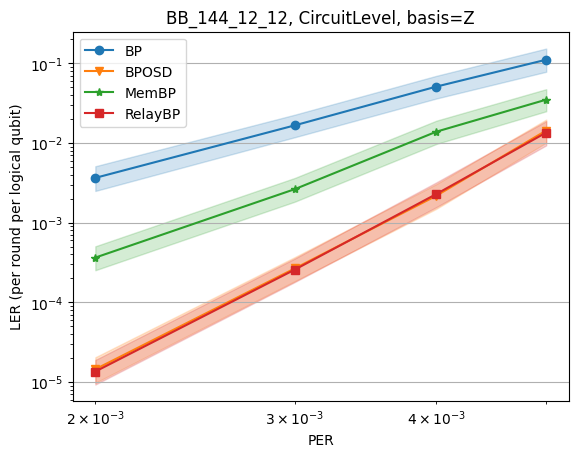

In [26]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=cmp_stats_Z_basis,
    group_func=lambda stat: f"{stat.json_metadata['decoder']}",
    failure_units_per_shot_func=lambda _: rounds,
    failure_values_func=lambda _: k,
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per round per logical qubit)")
ax.set_xlabel("PER")
ax.set_title(f"{code_name}, {noise_model}, basis=Z")
ax.legend()

plt.show()

In [ ]:
cmp_tasks_X_basis, cmp_custom_decoders_X_basis = generate_comparison_tasks("X")

cmp_stats_X_basis = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=cmp_tasks_X_basis,
    custom_decoders=cmp_custom_decoders_X_basis,
    print_progress=True,
)

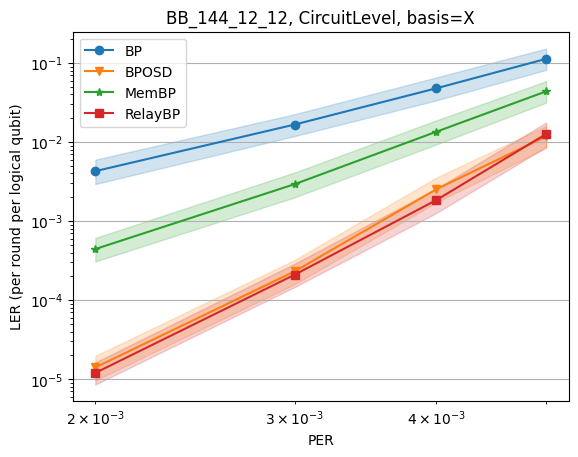

In [29]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=cmp_stats_X_basis,
    group_func=lambda stat: f"{stat.json_metadata['decoder']}",
    failure_units_per_shot_func=lambda _: rounds,
    failure_values_func=lambda _: k,
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per round per logical qubit)")
ax.set_xlabel("PER")
ax.set_title(f"{code_name}, {noise_model}, basis=X")
ax.legend()

plt.show()